# Calendar Puzzle Solver

Quebra-cabeça de madeira com **8 peças** num tabuleiro **7×8**.
O objetivo é cobrir todas as células, deixando expostos apenas o **mês** e o **dia** desejados.

| | |
|---|---|
| Tabuleiro | 7 linhas × 8 colunas = **55 células válidas** |
| Meses | Jan–Dez, cada um ocupa 2 células (total: 24) |
| Dias | 1–31, cada um ocupa 1 célula (total: 31) |
| Peças | 8 peças que cobrem **52 células** (55 − 2 do mês − 1 do dia) |

In [1]:
import sys, time
sys.path.insert(0, r'c:\Users\Gustavo\Desktop\calendar-puzzle-solver')

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from puzzles import PUZZLES, all_orientations
puzzle = PUZZLES[1] # 0 = Padrão, 1 = Verde
from solver import solve, solve_all

# ──────────────────────────────────────────────
WORKERS = 1   # aumente para usar múltiplos núcleos (ex: 4, 8, os.cpu_count())
# ──────────────────────────────────────────────

import os
print(f'CPUs disponíveis: {os.cpu_count()}')
print(f'Workers configurados: {WORKERS}')
print('Tudo carregado!')

CPUs disponíveis: 28
Workers configurados: 1
Tudo carregado!


## 1. O Tabuleiro

In [2]:
for r in range(puzzle.rows):
    row = []
    for c in range(puzzle.cols):
        if (r, c) in puzzle.invalid:
            row.append(' -- ')
        else:
            row.append(f"{puzzle.board.get((r, c), ''):>4}")
    print(' '.join(row))

print(f'\nTotal de células válidas: {puzzle.num_cells}')

 Jan  Feb  Mar  Apr  May  Jun  -- 
 Jul  Aug  Sep  Oct  Nov  Dec  -- 
   1    2    3    4    5    6    7
   8    9   10   11   12   13   14
  15   16   17   18   19   20   21
  22   23   24   25   26   27   28
  29   30   31  --   --   --   -- 

Total de células válidas: 43


## 2. As 8 Peças

In [3]:
PIECE_SHAPES = [
    'oooo\n oo ',
    'ooo\nooo\n  o',
    'oooo\nooo ',
    'ooo\nooo',
    'o\no\no\no\nooo',
    'o\no\no\noooo',
    'o  \nooo\noo ',
    'oooo\noo  ',
]

for i, size in enumerate(puzzle.piece_sizes):
    n_orient = len(all_orientations(puzzle.pieces_raw[i]))
    n_pos    = len(puzzle.all_placements[i])
    print(f'P{i} | {size} células | {n_orient} orientações | {n_pos} posições válidas')
    print()

P0 | 5 células | 8 orientações | 151 posições válidas

P1 | 6 células | 2 orientações | 48 posições válidas

P2 | 5 células | 8 orientações | 154 posições válidas

P3 | 5 células | 4 orientações | 96 posições válidas

P4 | 5 células | 8 orientações | 154 posições válidas

P5 | 5 células | 8 orientações | 196 posições válidas

P6 | 5 células | 4 orientações | 80 posições válidas

P7 | 5 células | 4 orientações | 82 posições válidas



## 3. Solver — Primeira Solução

O algoritmo usa **backtracking** com **bitmasks de 55 bits** para representar quais células estão livres.
A heurística do *primeiro bit livre* força sempre tentar cobrir a célula mais à esquerda/topo, podando drasticamente a árvore de busca.

In [4]:

def draw_solution(solution, month, day, ax=None, title=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 6))

    exposed = {pos for pos, lbl in puzzle.board.items()
               if lbl == month or lbl == str(day)}
    cell_piece = {}
    for pi, mask in solution:
        for bit in range(puzzle.num_cells):
            if mask & (1 << bit):
                cell_piece[puzzle.idx_to_cell[bit]] = pi

    ax.set_xlim(0, puzzle.cols); ax.set_ylim(0, puzzle.rows)
    ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
    if title: ax.set_title(title, fontweight='bold', fontsize=12)

    for r in range(puzzle.rows):
        for c in range(puzzle.cols):
            lbl = puzzle.board.get((r, c), '')
            if (r, c) in puzzle.invalid:
                ax.add_patch(patches.Rectangle((c,r),1,1,fc='#2C3E50',ec='#1A252F'))
                ax.text(c+.5,r+.5,'×',ha='center',va='center',color='#566573')
                continue
            if (r, c) in exposed:
                fc, tc, ec, lw = '#FDFEFE', '#1E8449', '#27AE60', 2.5
            elif (r, c) in cell_piece:
                fc = puzzle.piece_colors[cell_piece[(r,c)]]
                h = fc.lstrip('#')
                lum = 0.299*int(h[0:2],16)+0.587*int(h[2:4],16)+0.114*int(h[4:6],16)
                tc = 'white' if lum < 140 else '#2C3E50'
                ec, lw = '#BDC3C7', 1
            else:
                fc, tc, ec, lw = '#ECF0F1', '#95A5A6', '#BDC3C7', 1
            ax.add_patch(patches.Rectangle((c,r),1,1,fc=fc,ec=ec,lw=lw))
            ax.text(c+.5,r+.5,lbl,ha='center',va='center',
                    fontsize=9,fontweight='bold',color=tc)

    for r in range(puzzle.rows):
        for c in range(puzzle.cols):
            if (r,c) not in cell_piece: continue
            pi = cell_piece[(r,c)]
            if cell_piece.get((r,c+1)) != pi: ax.plot([c+1,c+1],[r,r+1],color='#5D6D7E',lw=2)
            if cell_piece.get((r+1,c)) != pi: ax.plot([c,c+1],[r+1,r+1],color='#5D6D7E',lw=2)

    if standalone:
        plt.tight_layout(); plt.show()

Solução para Apr 30 encontrada em 1.0 ms  (workers=1)


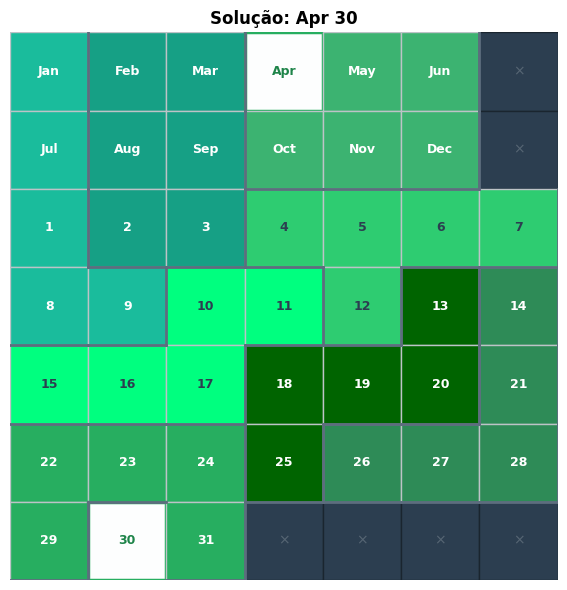

In [5]:
MONTH, DAY = puzzle.months[3], 30

t0 = time.perf_counter()
solution = solve(puzzle, MONTH, DAY, workers=WORKERS)
elapsed  = time.perf_counter() - t0

print(f'Solução para {MONTH} {DAY} encontrada em {elapsed*1000:.1f} ms  (workers={WORKERS})')
draw_solution(solution, MONTH, DAY, title=f'Solução: {MONTH} {DAY}')

## 4. Todas as Soluções para uma Data

In [6]:
FULL_MASK = (1 << puzzle.num_cells) - 1

# Versão didática do algoritmo (workers=1).
# A versão paralela está em solver.py e é usada automaticamente via WORKERS.
def solve_all_demo(month, day):
    """Backtracking simples para fins de demonstração."""
    exposed = 0
    for pos, lbl in puzzle.board.items():
        if lbl == month or lbl == str(day):
            exposed |= 1 << puzzle.cell_to_idx[pos]

    available = FULL_MASK & ~exposed
    solutions = []

    def backtrack(avail, remaining, placed):
        if not remaining:
            if avail == 0:
                solutions.append(list(placed))
            return
        target = (avail & -avail).bit_length() - 1
        for i, pi in enumerate(remaining):
            rest = remaining[:i] + remaining[i+1:]
            for mask in puzzle.placements_by_cell[pi][target]:
                if (mask & avail) == mask:
                    placed.append((pi, mask))
                    backtrack(avail ^ mask, rest, placed)
                    placed.pop()

    backtrack(available, list(range(puzzle.num_pieces)), [])
    return solutions

Jan 1: 64 soluções em 0.08s  (workers=1)


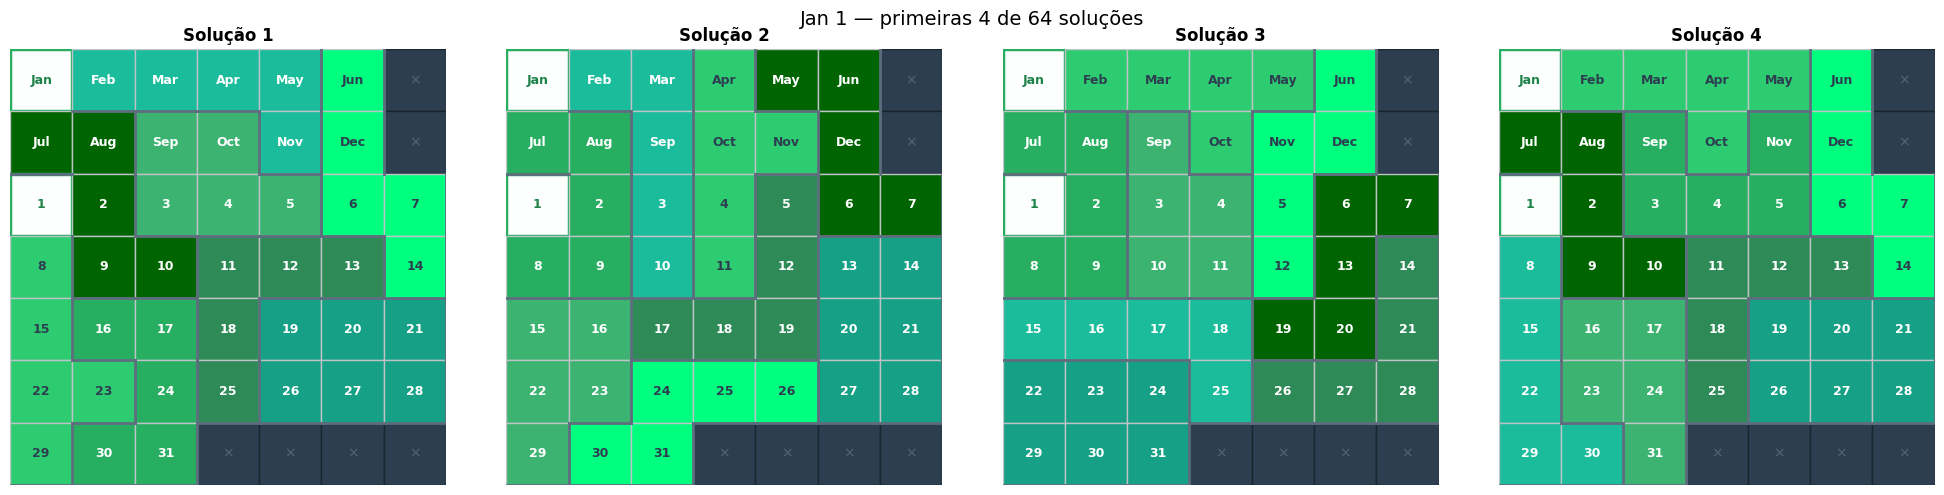

In [7]:
MONTH, DAY = puzzle.months[0], 1

t0 = time.perf_counter()
all_sols = solve_all(puzzle, MONTH, DAY, workers=WORKERS)
elapsed  = time.perf_counter() - t0

print(f'{MONTH} {DAY}: {len(all_sols)} soluções em {elapsed:.2f}s  (workers={WORKERS})')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, ax in enumerate(axes):
    draw_solution(all_sols[i], MONTH, DAY, ax=ax, title=f'Solução {i+1}')
plt.suptitle(f'{MONTH} {DAY} — primeiras 4 de {len(all_sols)} soluções', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Soluções para o Ano Completo

Calculando o número de soluções para cada combinação de **mês × dia** (12 × 31 = 372 datas).  
O resultado é exibido como um **heatmap**: quanto mais escuro, mais soluções existem.

Jan:   0%|          | 0/31 [00:00<?, ?dia/s]

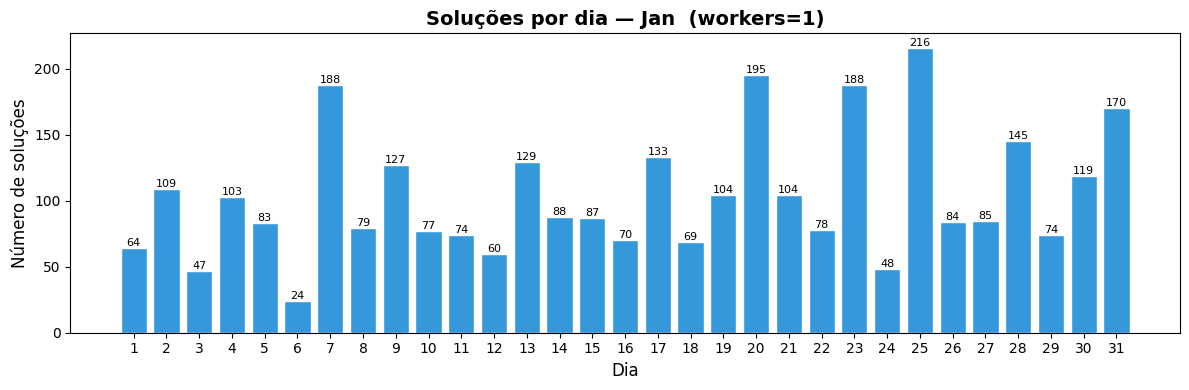

In [8]:
from tqdm.notebook import tqdm

TARGET_MONTH = puzzle.months[0]
counts = {}

for day in tqdm(range(1, 32), desc=TARGET_MONTH, unit="dia"):
    counts[day] = len(solve_all(puzzle, TARGET_MONTH, day, workers=WORKERS))

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(list(counts.keys()), list(counts.values()),
              color='#3498DB', edgecolor='white')
ax.bar_label(bars, fontsize=8)
ax.set_xlabel('Dia', fontsize=12)
ax.set_ylabel('Número de soluções', fontsize=12)
ax.set_title(f'Soluções por dia — {TARGET_MONTH}  (workers={WORKERS})', fontsize=14, fontweight='bold')
ax.set_xticks(list(counts.keys()))
plt.tight_layout()
plt.show()

Ano completo:   0%|          | 0/372 [00:00<?, ?data/s]

Total de soluções no ano: 25061  (workers=1)

✓ Todas as 372 datas têm pelo menos uma solução!


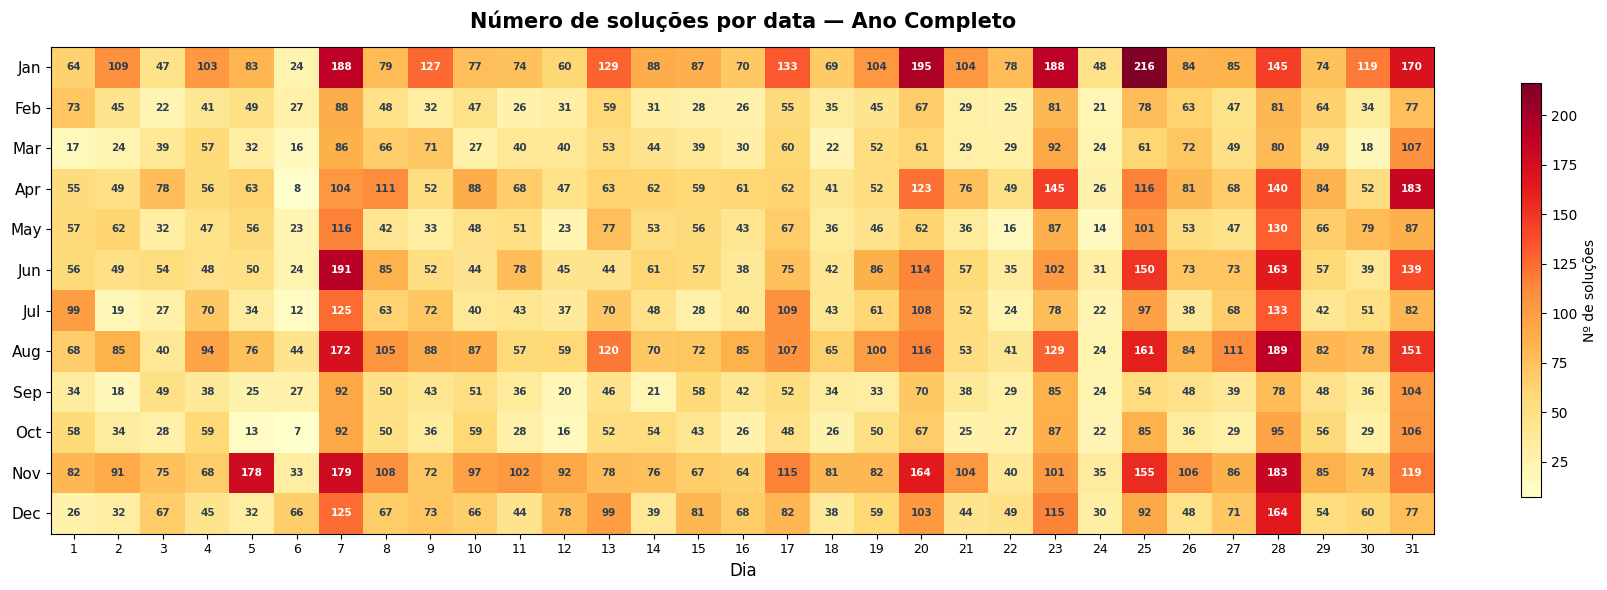

In [9]:
import numpy as np
from tqdm.notebook import tqdm

dates = [(m, d) for m in puzzle.months for d in range(1, 32)]
year_counts = {}

for month, day in tqdm(dates, desc="Ano completo", unit="data"):
    year_counts.setdefault(month, {})[day] = len(solve_all(puzzle, month, day, workers=WORKERS))

grand_total = sum(v for m in year_counts.values() for v in m.values())
print(f"Total de soluções no ano: {grand_total}  (workers={WORKERS})")

# Datas sem solução
sem_solucao = [(m, d) for m, d in dates if year_counts[m][d] == 0]
if sem_solucao:
    print(f"\n⚠ Datas sem solução ({len(sem_solucao)}):")
    for m, d in sem_solucao:
        print(f"  {m} {d}")
else:
    print("\n✓ Todas as 372 datas têm pelo menos uma solução!")

# Heatmap 12 meses × 31 dias
data = np.array([[year_counts[m][d] for d in range(1, 32)] for m in puzzle.months])

fig, ax = plt.subplots(figsize=(18, 6))
im = ax.imshow(data, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(31))
ax.set_xticklabels(range(1, 32), fontsize=9)
ax.set_yticks(range(12))
ax.set_yticklabels(puzzle.months, fontsize=11)
ax.set_xlabel('Dia', fontsize=12)
ax.set_title('Número de soluções por data — Ano Completo', fontsize=15, fontweight='bold', pad=14)

threshold = data.max() * 0.55
for i in range(12):
    for j in range(31):
        val = data[i, j]
        color = 'white' if val > threshold else '#2C3E50'
        ax.text(j, i, str(val), ha='center', va='center', fontsize=7.5,
                color=color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Nº de soluções', shrink=0.85)
plt.tight_layout()
plt.show()